In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("PJME_hourly.csv")

In [4]:
df.head()

,Datetime,PJME_MW
0,2002-12-31 01:00:00,26498.0
1,2002-12-31 02:00:00,25147.0
2,2002-12-31 03:00:00,24574.0
3,2002-12-31 04:00:00,24393.0
4,2002-12-31 05:00:00,24860.0


In [5]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nData types:")
print(df.dtypes)

Shape: (145366, 2)

Columns:
Index(['Datetime', 'PJME_MW'], dtype='str')

Data types:
Datetime        str
PJME_MW     float64
dtype: object


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 145366 entries, 0 to 145365
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   Datetime  145366 non-null  str    
 1   PJME_MW   145366 non-null  float64
dtypes: float64(1), str(1)
memory usage: 4.9 MB


In [7]:
df.describe()

,PJME_MW
count,145366.000000
mean,32080.222831
std,6464.012166
min,14544.000000
25%,27573.000000
50%,31421.000000
75%,35650.000000
max,62009.000000


In [8]:
df["Datetime"] = pd.to_datetime(df["Datetime"])

In [9]:
df.dtypes

Datetime    datetime64[us]
PJME_MW            float64
dtype: object

In [10]:
df = df.sort_values("Datetime").reset_index(drop=True)
df.head()

,Datetime,PJME_MW
0,2002-01-01 01:00:00,30393.0
1,2002-01-01 02:00:00,29265.0
2,2002-01-01 03:00:00,28357.0
3,2002-01-01 04:00:00,27899.0
4,2002-01-01 05:00:00,28057.0


In [11]:
df.tail()

,Datetime,PJME_MW
145361,2018-08-02 20:00:00,44057.0
145362,2018-08-02 21:00:00,43256.0
145363,2018-08-02 22:00:00,41552.0
145364,2018-08-02 23:00:00,38500.0
145365,2018-08-03 00:00:00,35486.0


In [12]:
df.isnull().sum()

Datetime    0
PJME_MW     0
dtype: int64

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
print("Start date:", df["Datetime"].min())
print("End date:", df["Datetime"].max())

print("\nTime difference between rows:")
print(df["Datetime"].diff().value_counts().head(10))

Start date: 2002-01-01 01:00:00
End date: 2018-08-03 00:00:00

Time difference between rows:
Datetime
0 days 01:00:00    145331
0 days 02:00:00        30
0 days 00:00:00         4
Name: count, dtype: int64


In [15]:
time_diff = df["Datetime"].diff()

unusual = df[time_diff != pd.Timedelta(hours=1)]

unusual[["Datetime", "PJME_MW"]].head(50)

,Datetime,PJME_MW
0,2002-01-01 01:00:00,30393.0
2306,2002-04-07 04:00:00,24487.0
7176,2002-10-27 03:00:00,20605.0
11040,2003-04-06 04:00:00,22902.0
15910,2003-10-26 03:00:00,20641.0
19774,2004-04-04 04:00:00,23208.0
24812,2004-10-31 03:00:00,20585.0
28508,2005-04-03 04:00:00,23414.0
33546,2005-10-30 03:00:00,23302.0
37242,2006-04-02 04:00:00,20833.0


In [16]:
print("Number of unusual rows:", len(unusual))

Number of unusual rows: 35


In [17]:
df.loc[78335:78347]

,Datetime,PJME_MW
78335,2010-12-09 18:00:00,42502.0
78336,2010-12-09 19:00:00,42744.0
78337,2010-12-09 20:00:00,42411.0
78338,2010-12-09 21:00:00,41851.0
78339,2010-12-09 22:00:00,40288.0
78340,2010-12-09 23:00:00,37729.0
78341,2010-12-10 01:00:00,33163.0
78342,2010-12-10 02:00:00,32323.0
78343,2010-12-10 03:00:00,32016.0
78344,2010-12-10 04:00:00,32008.0


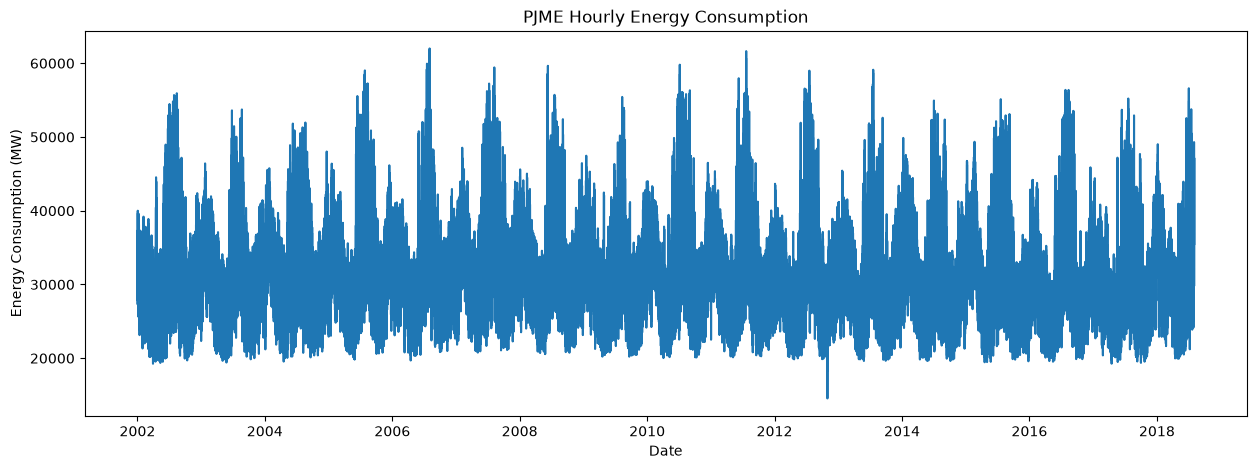

In [18]:
plt.figure(figsize=(15, 5))

plt.plot(df["Datetime"], df["PJME_MW"])

plt.title("PJME Hourly Energy Consumption")
plt.xlabel("Date")
plt.ylabel("Energy Consumption (MW)")
plt.show()

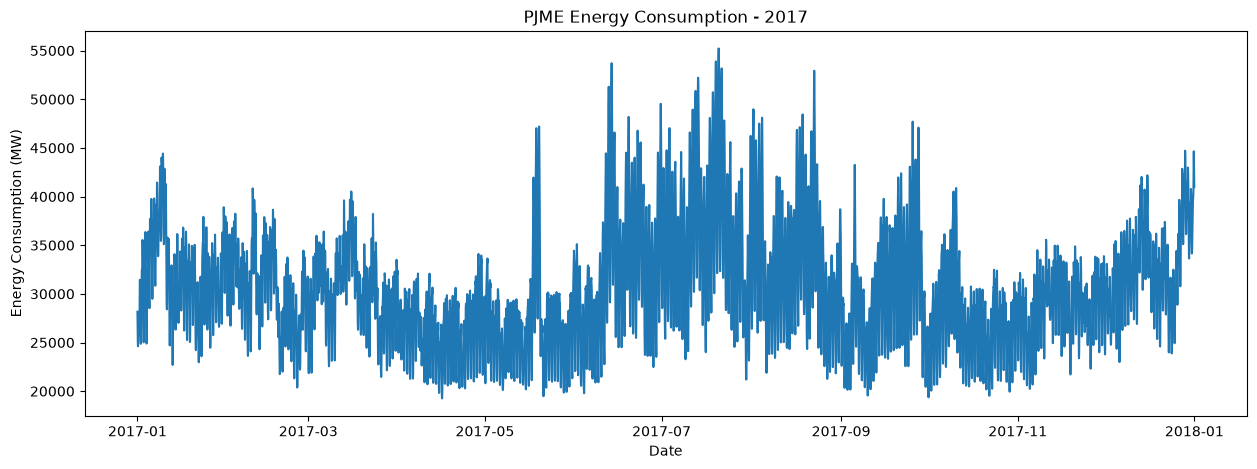

In [19]:
df_2017 = df[
    (df["Datetime"] >= "2017-01-01") &
    (df["Datetime"] < "2018-01-01")
]

plt.figure(figsize=(15, 5))

plt.plot(df_2017["Datetime"], df_2017["PJME_MW"])

plt.title("PJME Energy Consumption - 2017")
plt.xlabel("Date")
plt.ylabel("Energy Consumption (MW)")
plt.show()

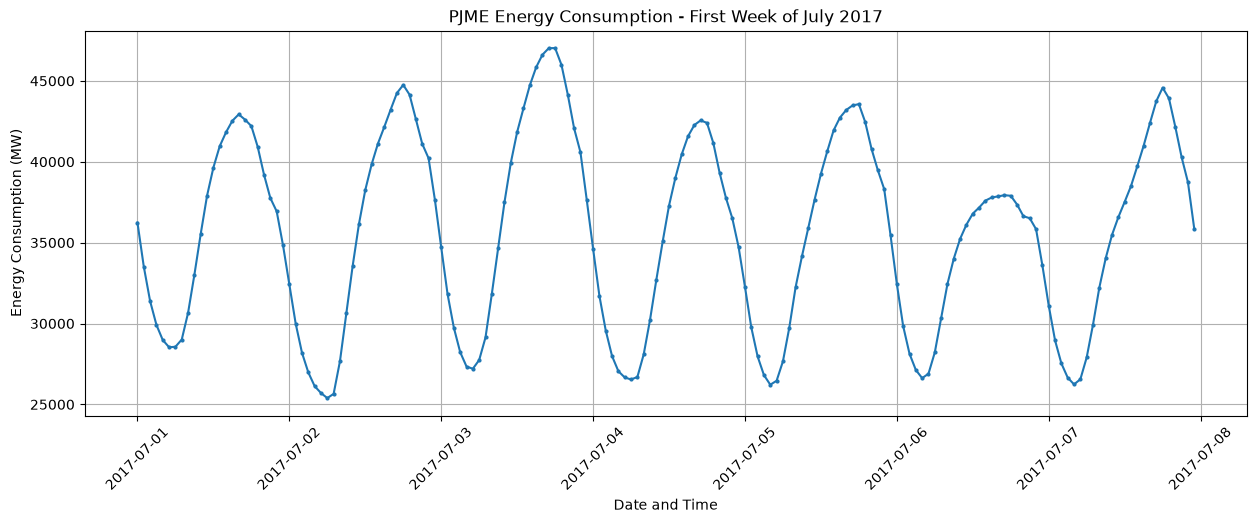

In [20]:
df_week = df[
    (df["Datetime"] >= "2017-07-01") &
    (df["Datetime"] < "2017-07-08")
]

plt.figure(figsize=(15, 5))

plt.plot(df_week["Datetime"], df_week["PJME_MW"], marker="o", markersize=2)

plt.title("PJME Energy Consumption - First Week of July 2017")
plt.xlabel("Date and Time")
plt.ylabel("Energy Consumption (MW)")
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

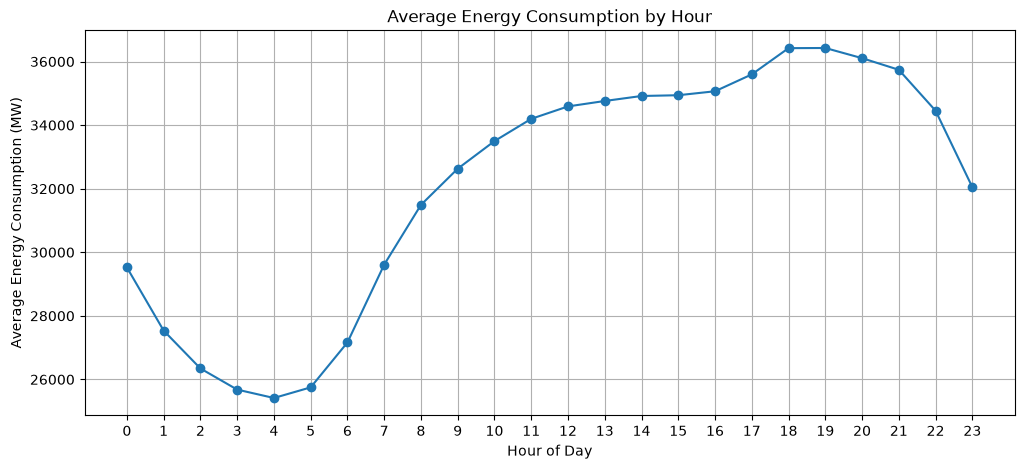

In [21]:
df["Hour"] = df["Datetime"].dt.hour

hourly_avg = df.groupby("Hour")["PJME_MW"].mean()

plt.figure(figsize=(12, 5))

plt.plot(hourly_avg.index, hourly_avg.values, marker="o")

plt.title("Average Energy Consumption by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Energy Consumption (MW)")
plt.xticks(range(24))
plt.grid(True)

plt.show()

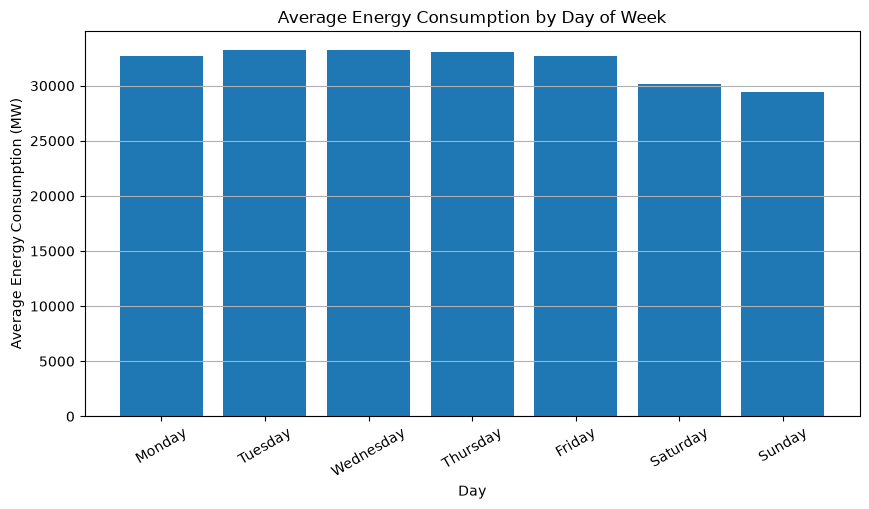

In [22]:
df["DayOfWeek"] = df["Datetime"].dt.dayofweek

day_avg = df.groupby("DayOfWeek")["PJME_MW"].mean()

plt.figure(figsize=(10, 5))

plt.bar(
    ["Monday", "Tuesday", "Wednesday", "Thursday",
     "Friday", "Saturday", "Sunday"],
    day_avg.values
)

plt.title("Average Energy Consumption by Day of Week")
plt.xlabel("Day")
plt.ylabel("Average Energy Consumption (MW)")
plt.xticks(rotation=30)
plt.grid(axis="y")

plt.show()

In [23]:
df["Hour"] = df["Datetime"].dt.hour
df["DayOfWeek"] = df["Datetime"].dt.dayofweek
df["Month"] = df["Datetime"].dt.month

df["Lag_1"] = df["PJME_MW"].shift(1)
df["Lag_24"] = df["PJME_MW"].shift(24)
df["Lag_168"] = df["PJME_MW"].shift(168)

df.head(20)

,Datetime,PJME_MW,Hour,DayOfWeek,Month,Lag_1,Lag_24,Lag_168
0,2002-01-01 01:00:00,30393.0,1,1,1,NaN,NaN,NaN
1,2002-01-01 02:00:00,29265.0,2,1,1,30393.0,NaN,NaN
2,2002-01-01 03:00:00,28357.0,3,1,1,29265.0,NaN,NaN
3,2002-01-01 04:00:00,27899.0,4,1,1,28357.0,NaN,NaN
4,2002-01-01 05:00:00,28057.0,5,1,1,27899.0,NaN,NaN
5,2002-01-01 06:00:00,28654.0,6,1,1,28057.0,NaN,NaN
6,2002-01-01 07:00:00,29308.0,7,1,1,28654.0,NaN,NaN
7,2002-01-01 08:00:00,29595.0,8,1,1,29308.0,NaN,NaN
8,2002-01-01 09:00:00,29943.0,9,1,1,29595.0,NaN,NaN
9,2002-01-01 10:00:00,30692.0,10,1,1,29943.0,NaN,NaN


In [24]:
df = df.dropna().reset_index(drop=True)
print("New shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())

New shape: (145198, 8)

Missing values:
Datetime     0
PJME_MW      0
Hour         0
DayOfWeek    0
Month        0
Lag_1        0
Lag_24       0
Lag_168      0
dtype: int64


In [25]:
train_size = int(len(df) * 0.8)

train = df.iloc[:train_size]
test = df.iloc[train_size:]

print("Training shape:", train.shape)
print("Testing shape:", test.shape)

print("\nTraining period:")
print(train["Datetime"].min(), "to", train["Datetime"].max())

print("\nTesting period:")
print(test["Datetime"].min(), "to", test["Datetime"].max())

Training shape: (116158, 8)
Testing shape: (29040, 8)

Training period:
2002-01-08 01:00:00 to 2015-04-11 00:00:00

Testing period:
2015-04-11 01:00:00 to 2018-08-03 00:00:00


In [26]:
features = [
    "Hour",
    "DayOfWeek",
    "Month",
    "Lag_1",
    "Lag_24",
    "Lag_168"
]

X_train = train[features]
y_train = train["PJME_MW"]

X_test = test[features]
y_test = test["PJME_MW"]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (116158, 6)
y_train: (116158,)
X_test: (29040, 6)
y_test: (29040,)


In [27]:
!pip install xgboost -q

In [28]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)

In [29]:
model.fit(X_train, y_train)
print("Model training completed!")

Model training completed!


In [30]:
y_pred = model.predict(X_test)

print("Predictions generated!")
print("Number of predictions:", len(y_pred))

Predictions generated!
Number of predictions: 29040


In [31]:
comparison = pd.DataFrame({
    "Actual": y_test.values[:10],
    "Predicted": y_pred[:10]
})

comparison

,Actual,Predicted
0,23728.0,23626.425781
1,22743.0,22798.726562
2,22276.0,22247.435547
3,22029.0,22027.601562
4,22248.0,22108.332031
5,23000.0,22946.902344
6,24053.0,24276.074219
7,25079.0,25694.400391
8,25947.0,27085.035156
9,26327.0,27330.439453


In [32]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2 = r2_score(y_test, y_pred)

print("Model Performance")
print("------------------")
print(f"MAE  : {mae:.2f} MW")
print(f"RMSE : {rmse:.2f} MW")
print(f"R²   : {r2:.4f}")

Model Performance
------------------
MAE  : 327.37 MW
RMSE : 445.64 MW
R²   : 0.9953


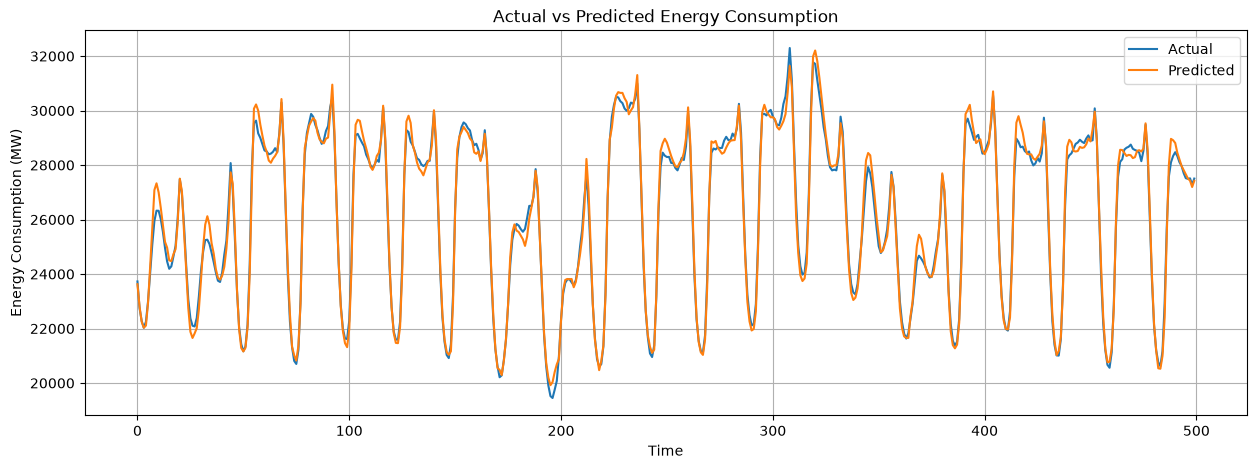

In [33]:
plt.figure(figsize=(15, 5))

plt.plot(y_test.values[:500], label="Actual")
plt.plot(y_pred[:500], label="Predicted")

plt.title("Actual vs Predicted Energy Consumption")
plt.xlabel("Time")
plt.ylabel("Energy Consumption (MW)")
plt.legend()
plt.grid(True)

plt.show()

In [34]:
importance = pd.Series(
    model.feature_importances_,
    index=features
).sort_values(ascending=False)

print(importance)

Lag_1        0.626292
Lag_24       0.263339
Lag_168      0.041894
Hour         0.030884
DayOfWeek    0.030633
Month        0.006958
dtype: float32


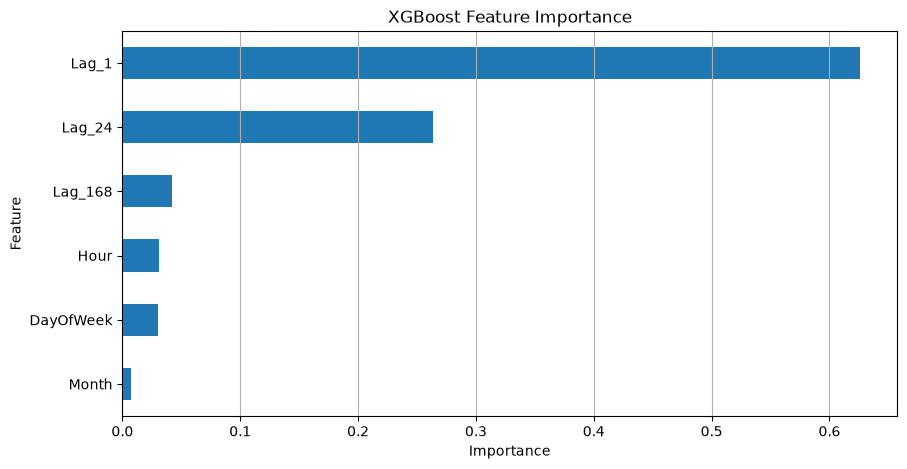

In [35]:
plt.figure(figsize=(10, 5))

importance.sort_values().plot(kind="barh")

plt.title("XGBoost Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.grid(axis="x")

plt.show()

In [36]:
import joblib

joblib.dump(model, "energy_forecasting_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [37]:
joblib.dump(features, "model_features.pkl")

print("Feature list saved successfully!")

Feature list saved successfully!


In [38]:
%%writefile app.py

import streamlit as st
import pandas as pd
import joblib

# Load model
model = joblib.load("energy_forecasting_model.pkl")
features = joblib.load("model_features.pkl")

st.set_page_config(
    page_title="Energy Consumption Forecasting",
    page_icon="⚡",
    layout="centered"
)

st.title("⚡ Energy Consumption Forecasting")

st.write(
    "Predict electricity consumption using historical consumption "
    "and time-based features."
)

st.subheader("Enter Forecast Information")

hour = st.slider("Hour of Day", 0, 23, 12)
day_of_week = st.slider("Day of Week", 0, 6, 0)
month = st.slider("Month", 1, 12, 1)

lag_1 = st.number_input(
    "Energy Consumption 1 Hour Ago (MW)",
    min_value=0.0,
    value=30000.0
)

lag_24 = st.number_input(
    "Energy Consumption 24 Hours Ago (MW)",
    min_value=0.0,
    value=30000.0
)

lag_168 = st.number_input(
    "Energy Consumption 7 Days Ago (MW)",
    min_value=0.0,
    value=30000.0
)

if st.button("Predict Energy Consumption"):

    input_data = pd.DataFrame([[
        hour,
        day_of_week,
        month,
        lag_1,
        lag_24,
        lag_168
    ]], columns=features)

    prediction = model.predict(input_data)[0]

    st.success(
        f"Predicted Energy Consumption: {prediction:,.2f} MW"
    )

Writing app.py


In [39]:
!pip install streamlit

In [40]:
!streamlit --version

Streamlit, version 1.58.0


In [43]:
import streamlit as st
import pandas as pd
import joblib

# =========================================================
# PAGE CONFIG
# =========================================================

st.set_page_config(
    page_title="WattWise | Energy Forecast",
    page_icon="⚡",
    layout="wide",
    initial_sidebar_state="expanded"
)

# =========================================================
# LOAD MODEL
# =========================================================

model = joblib.load("energy_forecasting_model.pkl")
features = joblib.load("model_features.pkl")

# =========================================================
# CUSTOM CSS
# =========================================================

st.markdown(
    """
<style>

/* =======================================================
   GLOBAL
======================================================= */

.stApp {
    background:
        radial-gradient(
            circle at 10% 10%,
            rgba(0, 255, 170, 0.08),
            transparent 25%
        ),
        radial-gradient(
            circle at 90% 20%,
            rgba(0, 180, 255, 0.08),
            transparent 25%
        ),
        #07111f;

    color: #f5f7fa;
}

.main {
    padding-top: 1rem;
}


/* =======================================================
   SIDEBAR
======================================================= */

section[data-testid="stSidebar"] {
    background: #050d18;
    border-right: 1px solid rgba(255,255,255,0.08);
}


/* =======================================================
   HERO
======================================================= */

.hero {
    padding: 35px 40px;
    border-radius: 24px;

    background:
        linear-gradient(
            135deg,
            rgba(0,255,170,0.12),
            rgba(0,170,255,0.08)
        );

    border: 1px solid rgba(0,255,170,0.15);

    margin-bottom: 25px;
}

.hero-title {
    font-size: 42px;
    font-weight: 800;
    margin-bottom: 8px;
    letter-spacing: -1px;
}

.hero-title span {
    color: #00e6a7;
}

.hero-subtitle {
    color: #a9b7c8;
    font-size: 17px;
}


/* =======================================================
   SECTION HEADERS
======================================================= */

.section-title {
    font-size: 22px;
    font-weight: 700;
    margin-top: 10px;
    margin-bottom: 15px;
    color: #ffffff;
}


/* =======================================================
   GLASS CARDS
======================================================= */

.glass-card {
    background: rgba(255,255,255,0.035);

    border: 1px solid rgba(255,255,255,0.08);

    border-radius: 20px;

    padding: 22px;

    margin-bottom: 18px;

    backdrop-filter: blur(10px);
}


/* =======================================================
   PREDICTION CARD
======================================================= */

.metric-card {
    background:
        linear-gradient(
            135deg,
            rgba(0,230,167,0.14),
            rgba(0,150,255,0.08)
        );

    border: 1px solid rgba(0,230,167,0.18);

    border-radius: 22px;

    padding: 28px;

    text-align: center;
}

.metric-label {
    color: #9baabd;

    font-size: 14px;

    text-transform: uppercase;

    letter-spacing: 1px;
}

.metric-value {
    font-size: 38px;

    font-weight: 800;

    color: #00e6a7;

    margin-top: 8px;
}

.metric-unit {
    color: #b5c0ce;

    font-size: 15px;
}


/* =======================================================
   BADGES
======================================================= */

.badge {
    display: inline-block;

    padding: 7px 13px;

    border-radius: 20px;

    background: rgba(0,230,167,0.10);

    border: 1px solid rgba(0,230,167,0.18);

    color: #00e6a7;

    font-size: 13px;

    margin-right: 5px;
}


/* =======================================================
   BUTTON
======================================================= */

.stButton > button {
    width: 100%;

    border-radius: 14px;

    border: none;

    padding: 14px 20px;

    font-size: 17px;

    font-weight: 700;

    background:
        linear-gradient(
            90deg,
            #00e6a7,
            #00b7ff
        );

    color: #041018;

    transition: 0.25s;
}

.stButton > button:hover {
    transform: translateY(-2px);

    box-shadow:
        0 8px 25px
        rgba(0,230,167,0.20);
}


/* =======================================================
   INPUTS
======================================================= */

div[data-baseweb="input"],
div[data-baseweb="select"] {
    border-radius: 12px;
}


/* =======================================================
   FOOTER
======================================================= */

.footer {
    text-align: center;

    color: #667589;

    padding: 30px 0 10px 0;

    font-size: 13px;
}

</style>
""",
    unsafe_allow_html=True
)


# =========================================================
# SIDEBAR
# =========================================================

with st.sidebar:

    st.markdown("## ⚡ WattWise")

    st.markdown(
        """
<p style="color:#91a0b3;">
AI-powered electricity consumption forecasting.
</p>
""",
        unsafe_allow_html=True
    )

    st.markdown("---")

    st.markdown("### 🧠 Model")

    st.markdown(
        """
<span class="badge">XGBoost</span>
<span class="badge">Regression</span>
""",
        unsafe_allow_html=True
    )

    st.markdown("")

    st.markdown("### 📊 Model Performance")

    st.metric("R² Score", "99.56%")

    st.metric("MAE", "318.53 MW")

    st.metric("RMSE", "432.89 MW")

    st.markdown("---")

    st.markdown(
        """
### 📌 Features Used

• Previous hour  
• Previous day  
• Previous week  
• Hour of day  
• Day of week  
• Month
"""
    )

    st.markdown("---")

    st.caption(
        "HCL P_203 • Energy Consumption Forecasting"
    )


# =========================================================
# HERO
# =========================================================

st.markdown(
    """
<div class="hero">
<div class="hero-title">⚡ <span>WattWise</span></div>
<div class="hero-subtitle">
Intelligent Energy Consumption Forecasting powered by Machine Learning
</div>
</div>
""",
    unsafe_allow_html=True
)


# =========================================================
# FORECAST CONFIGURATION
# =========================================================

st.markdown(
    '<div class="section-title">🎛️ Forecast Configuration</div>',
    unsafe_allow_html=True
)

left, right = st.columns(2)


# =========================================================
# LEFT CARD: TIME INFORMATION
# =========================================================

with left:

    st.markdown(
        '<div class="glass-card">',
        unsafe_allow_html=True
    )

    st.markdown("### 🕒 Time Information")

    # -----------------------------
    # Hour
    # -----------------------------

    hour = st.slider(
        "Hour of Day",
        min_value=0,
        max_value=23,
        value=12
    )

    # -----------------------------
    # Day
    # -----------------------------

    days = [
        "Monday",
        "Tuesday",
        "Wednesday",
        "Thursday",
        "Friday",
        "Saturday",
        "Sunday"
    ]

    day_of_week = st.selectbox(
        "Day of Week",
        options=list(range(7)),
        format_func=lambda x: days[x],
        index=2
    )

    # -----------------------------
    # Month
    # -----------------------------

    months = [
        "January",
        "February",
        "March",
        "April",
        "May",
        "June",
        "July",
        "August",
        "September",
        "October",
        "November",
        "December"
    ]

    month = st.selectbox(
        "Month",
        options=list(range(1, 13)),
        format_func=lambda x: months[x - 1],
        index=6
    )

    st.markdown(
        '</div>',
        unsafe_allow_html=True
    )


# =========================================================
# RIGHT CARD: HISTORICAL CONSUMPTION
# =========================================================

with right:

    st.markdown(
        '<div class="glass-card">',
        unsafe_allow_html=True
    )

    st.markdown("### ⚡ Historical Consumption")

    lag_1 = st.number_input(
        "Previous Hour (MW)",
        min_value=0.0,
        max_value=100000.0,
        value=30000.0,
        step=100.0
    )

    lag_24 = st.number_input(
        "Previous Day, Same Hour (MW)",
        min_value=0.0,
        max_value=100000.0,
        value=30000.0,
        step=100.0
    )

    lag_168 = st.number_input(
        "Previous Week, Same Hour (MW)",
        min_value=0.0,
        max_value=100000.0,
        value=30000.0,
        step=100.0
    )

    st.markdown(
        '</div>',
        unsafe_allow_html=True
    )


# =========================================================
# HISTORICAL SIGNAL VISUALIZATION
# =========================================================

st.markdown(
    '<div class="section-title">📈 Historical Consumption Signals</div>',
    unsafe_allow_html=True
)

chart_data = pd.DataFrame(
    {
        "Period": [
            "Previous Hour",
            "Previous Day",
            "Previous Week"
        ],

        "Consumption (MW)": [
            lag_1,
            lag_24,
            lag_168
        ]
    }
)

st.bar_chart(
    chart_data.set_index("Period"),
    height=280
)


# =========================================================
# FORECAST SECTION
# =========================================================

st.markdown(
    '<div class="section-title">🔮 Forecast</div>',
    unsafe_allow_html=True
)


# =========================================================
# PREDICTION BUTTON
# =========================================================

if st.button("⚡ Generate Energy Forecast"):

    # -----------------------------------------------------
    # CREATE MODEL INPUT
    # -----------------------------------------------------

    input_data = pd.DataFrame(
        [
            [
                hour,
                day_of_week,
                month,
                lag_1,
                lag_24,
                lag_168
            ]
        ],
        columns=features
    )

    # -----------------------------------------------------
    # PREDICTION
    # -----------------------------------------------------

    prediction = model.predict(input_data)[0]

    # -----------------------------------------------------
    # MAIN PREDICTION CARD
    # -----------------------------------------------------

    st.markdown(
        f"""
<div class="metric-card">

<div class="metric-label">
Predicted Energy Consumption
</div>

<div class="metric-value">
{prediction:,.2f}
</div>

<div class="metric-unit">
Megawatts (MW)
</div>

</div>
""",
        unsafe_allow_html=True
    )

    st.markdown("")

    # -----------------------------------------------------
    # INPUT SUMMARY
    # -----------------------------------------------------

    col1, col2, col3 = st.columns(3)

    with col1:

        st.metric(
            "Previous Hour",
            f"{lag_1:,.0f} MW"
        )

    with col2:

        st.metric(
            "Previous Day",
            f"{lag_24:,.0f} MW"
        )

    with col3:

        st.metric(
            "Previous Week",
            f"{lag_168:,.0f} MW"
        )

    # -----------------------------------------------------
    # FORECAST INSIGHT
    # -----------------------------------------------------

    average_history = (
        lag_1 +
        lag_24 +
        lag_168
    ) / 3

    difference = prediction - average_history

    st.markdown("### 💡 Forecast Insight")

    if difference > 1000:

        st.info(
            f"""
The model predicts **{prediction:,.0f} MW**.

This is approximately **{abs(difference):,.0f} MW higher**
than the average of the three historical reference values.
"""
        )

    elif difference < -1000:

        st.info(
            f"""
The model predicts **{prediction:,.0f} MW**.

This is approximately **{abs(difference):,.0f} MW lower**
than the average of the three historical reference values.
"""
        )

    else:

        st.info(
            f"""
The model predicts **{prediction:,.0f} MW**,
which is close to the average of the historical
reference values.
"""
        )


# =========================================================
# MODEL EXPLANATION
# =========================================================

with st.expander("🧠 How does this model work?"):

    st.markdown(
        """
### XGBoost Energy Forecasting

The model learns relationships between historical
electricity consumption and time-based patterns.

### Input Signals

- Previous hour consumption
- Previous day consumption
- Previous week consumption
- Hour of day
- Day of week
- Month

### Machine Learning Model

**XGBoost Regression**

### Test Performance

| Metric | Value |
|---|---:|
| MAE | 318.53 MW |
| RMSE | 432.89 MW |
| R² | 0.9956 |

The model currently performs a **one-step-ahead
prediction** using the supplied historical
consumption values.
"""
    )


# =========================================================
# FOOTER
# =========================================================

st.markdown(
    """
<div class="footer">

⚡ WattWise Energy Forecasting<br>

HCL Project P_203 • Machine Learning • XGBoost

</div>
""",
    unsafe_allow_html=True
)

2026-09-30 11:53:23.384 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-30 11:53:23.419 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-30 11:53:24.074 
  command:

    streamlit run C:\Users\harsh\anaconda3\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-09-30 11:53:24.075 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-30 11:53:24.075 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-30 11:53:24.077 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-30 11:53:24.077 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when runn

DeltaGenerator()